# 02b. Characterize the fitted Isolation Forest

This notebook characterizes the final model fitted in `02_fit_isolation_forest.ipynb` without changing the model used downstream. Isolation Forest has no linear coefficients or native `feature_importances_`, so the notebook reports complementary diagnostics rather than calling any single quantity a feature weight.

The analysis has four parts:

1. exact reproduction of the saved model scores and T95 threshold;
2. fixed-model permutation influence;
3. leave-one-feature-out refits compared with between-seed stochastic stability;
4. local neutral-replacement perturbations for top and selected variants.

Positive local perturbation values mean that the observed feature value makes the variant more anomalous than replacements drawn from the neutral-training distribution. They are not additive SHAP values and should not be interpreted as causal effects.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.ensemble import IsolationForest
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 240)

In [2]:
# ============================================================
# Paths and deterministic configuration
# ============================================================

SCORED_INPUT = Path("../results/model/isolation_forest_scores_all_thresholds.tsv")
THRESHOLD_INPUT = Path("../results/model/isolation_forest_thresholds_all.tsv")
OUTPUT_DIR = Path("../results/model_characterization")
FIGURE_DIR = Path("../results/figures/model_characterization")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_PROFILE_OUTPUT = OUTPUT_DIR / "feature_profile.tsv"
RECONSTRUCTION_QC_OUTPUT = OUTPUT_DIR / "model_reconstruction_qc.tsv"
FEATURE_CORRELATION_OUTPUT = OUTPUT_DIR / "feature_correlations_spearman.tsv"
PERMUTATION_DETAIL_OUTPUT = OUTPUT_DIR / "permutation_influence_repeats.tsv"
PERMUTATION_SUMMARY_OUTPUT = OUTPUT_DIR / "permutation_influence_summary.tsv"
LOFO_DETAIL_OUTPUT = OUTPUT_DIR / "leave_one_feature_out_repeats.tsv"
LOFO_SUMMARY_OUTPUT = OUTPUT_DIR / "leave_one_feature_out_summary.tsv"
SEED_STABILITY_OUTPUT = OUTPUT_DIR / "full_model_seed_stability.tsv"
LOCAL_INFLUENCE_OUTPUT = OUTPUT_DIR / "local_neutral_replacement_influence.tsv"
FEATURE_SUMMARY_OUTPUT = OUTPUT_DIR / "feature_influence_summary.tsv"

FEATURE_COLS = [
    "mlc_score",
    "rarity_soft",
    "hom_rarity_soft",
    "het_rarity_soft",
    "no_homoplasmic_signal",
    "codon_pos1_any",
    "codon_pos2_any",
    "codon_pos3_any",
    "phyloP100way",
]
SAVED_SCORE_COL = "isolation_forest_outlier_score"
T95_FLAG_COL = "isolation_forest_above_T95"
RANDOM_STATE = 42
PERMUTATION_REPEATS = 5
LOFO_RANDOM_STATES = (42, 43, 44)
LOCAL_TOP_N = 20
LOCAL_REPLACEMENT_DRAWS = 200
SELECTED_LOCAL_VARIANTS = (
    "m.14149C>A", "m.16519T>C", "m.750A>G", "m.15326A>G",
)

## Как Isolation Forest принимает решение

Isolation Forest не учится отличать pathogenic от neutral и не строит границу между двумя классами. Он видит только `neutral_train` и строит 500 случайных деревьев изоляции. В каждом узле случайно выбираются признак и порог между наблюдаемыми минимумом и максимумом. Вариант из плотной нейтральной области обычно требует много последовательных разбиений; редкий или необычный вариант отделяется коротким путём. Итоговый anomaly score является монотонным преобразованием средней длины пути по деревьям: чем короче путь, тем более аномален вариант.

В sklearn `decision_function` возрастает в сторону normal. В проекте сохраняется `outlier_score = -decision_function`, поэтому **большее значение означает больший выход из нейтрального домена**. Порог T95 — 95-й процентиль score на отдельной neutral-validation выборке. Таким образом, около 5% вариантов из сопоставимой нейтральной популяции ожидаемо окажутся выше порога даже при корректной модели. Это контроль хвоста нейтрального распределения, а не вероятность патогенности.

У модели нет коэффициентов и нет встроенных `feature_importances_`. На каждом split признаки формально выбираются случайно, без заранее назначенного веса. Признак приобретает фактическое влияние, если разбиения по нему систематически делают пути вариантов короче. `RobustScaler` не задаёт биологические веса; он только преобразует шкалы перед forest. При этом несколько коррелированных признаков одной биологической семьи дают этой семье больше возможностей участвовать в случайных разбиениях, поэтому отдельные rarity-признаки нельзя интерпретировать изолированно.

## Какие признаки сильнее влияют на T95-классификацию

В таблице сопоставлены две разные проверки. `Permutation flip` — доля вариантов, изменивших T95-статус после перемешивания признака при фиксированной модели. `LOFO flip` — доля изменивших статус после полного переобучения без признака и новой нейтральной калибровки T95. Обычная смена random seed у полной модели меняет в среднем 1,88% T95-вызовов; эффекты около этого уровня являются слабыми.

| Признак | Permutation flip | LOFO flip | Интерпретация |
|---|---:|---:|---|
| `phyloP100way` | 8,20% | **13,90%** | Самый сильный уникальный признак: без него модель перестраивает нейтральный домен сильнее всего. |
| `codon_pos2_any` | 8,78% | **8,75%** | Сильное и согласованное влияние в обеих проверках. |
| `no_homoplasmic_signal` | 6,14% | **8,68%** | Сильный population-level сигнал, особенно после переобучения. |
| `codon_pos1_any` | 5,24% | **7,10%** | Умеренно-сильное уникальное влияние. |
| `mlc_score` | **9,02%** | 6,51% | Максимально используется фиксированной моделью, но часть информации при LOFO компенсируется другими признаками. |
| `codon_pos3_any` | **8,97%** | 4,14% | Фиксированная модель сильно на него опирается, но после переобучения его частично заменяют другие codon indicators. |
| `het_rarity_soft` | 3,58% | 2,91% | Небольшое уникальное влияние; интерпретировать вместе с rarity-family. |
| `hom_rarity_soft` | 2,52% | 2,44% | Небольшое уникальное влияние; высокая взаимозаменяемость. |
| `rarity_soft` | 3,82% | 2,09% | LOFO-эффект лишь немного выше seed baseline; это не означает, что вся population-информация неважна. |

Практический общий вывод: наиболее устойчивое ядро влияния образуют **phyloP, codon-position family, MLC и отсутствие homoplasmic signal**. Самые слабые *уникальные* эффекты имеют три коррелированных rarity score. Для конкретного варианта порядок может быть другим — это показывает local neutral-replacement analysis, потому что Isolation Forest реагирует на комбинации признаков, а не на одну глобальную линейную сумму.

## В каком смысле Isolation Forest лучше — и в каком не лучше

Isolation Forest лучше соответствует **поставленной one-class задаче**, потому что надёжная большая выборка имеется только для neutral reference, а положительных Dataset 9 всего 84 и они курированы неслучайным образом. IF не обязан считать Dataset 9 полным описанием всех возможных функционально значимых вариантов; он спрашивает, совместим ли новый вариант с изученным нейтральным доменом. Это особенно полезно для новых механизмов, которые не похожи на известные pathogenic examples. Он также естественно учитывает нелинейные сочетания — например одновременно высокий MLC, высокая conservation и отсутствие homoplasmy.

Но IF **не лучше как supervised-классификатор известных neutral/pathogenic меток**. В grouped out-of-fold benchmark Random Forest разделяет эти две курированные группы лучше. Его преимущество, однако, сильно зависит от phyloP и правил формирования Dataset 8, а при применении ко всем unlabeled полный RF называет pathogenic-like 89,8% вариантов. Поэтому корректная методологическая формулировка такая: **Isolation Forest — основная модель для `Expanded neutral-like` против `Out of neutral domain`; Random Forest — дополнительная ось сходства с известными pathogenic вариантами.** Ни один из двух вызовов сам по себе не означает клиническую патогенность.

Наконец, высокая роль `phyloP100way` требует осторожности: низкий phyloP использовался при формировании части neutral reference. Поэтому результат может частично отражать критерий отбора Dataset 8. Это аргумент в пользу sensitivity analysis без phyloP и внешней валидации, а не повод автоматически исключать признак из текущей exploratory модели.

## Load the saved scoring table and reproduce the final model

Notebook 02 saves the exact nine model features and deterministic neutral train/validation membership, but it does not serialize the fitted forest. This notebook therefore refits the same `RobustScaler + IsolationForest(n_estimators=500, contamination='auto', random_state=42)` architecture and records its agreement with the saved scores. Exact equality is not assumed across sklearn runtimes; low rank or T95 agreement stops the analysis. All subsequent perturbations characterize this explicitly audited reconstruction.

In [3]:
scored = pd.read_csv(SCORED_INPUT, sep="\t", low_memory=False)
thresholds = pd.read_csv(THRESHOLD_INPUT, sep="\t")

required_cols = {
    "variant_id", "analysis_group", "neutral_split",
    SAVED_SCORE_COL, T95_FLAG_COL, *FEATURE_COLS,
}
missing_cols = sorted(required_cols.difference(scored.columns))
if missing_cols:
    raise ValueError(f"Missing model-characterization columns: {missing_cols}")
if scored[FEATURE_COLS].isna().any().any():
    raise ValueError("The saved model feature matrix contains missing values.")
if scored["variant_id"].duplicated().any():
    raise ValueError("Expected one scored row per variant_id.")

t95_rows = thresholds[thresholds["threshold_name"] == "T95"]
if len(t95_rows) != 1:
    raise ValueError("Expected exactly one saved T95 threshold.")
SAVED_T95_THRESHOLD = float(t95_rows["threshold_value"].iloc[0])

train_mask = scored["neutral_split"].eq("neutral_train").to_numpy()
validation_mask = scored["neutral_split"].eq("neutral_validation").to_numpy()
unlabeled_mask = scored["analysis_group"].eq("unlabeled_or_other").to_numpy()
X_all = scored[FEATURE_COLS].copy()
X_train = X_all.loc[train_mask].copy()

def fit_isolation_forest(feature_cols, random_state):
    pipeline = Pipeline([
        ("scaler", RobustScaler()),
        ("model", IsolationForest(
            n_estimators=500,
            contamination="auto",
            random_state=random_state,
            n_jobs=-1,
        )),
    ])
    pipeline.fit(X_train[feature_cols])
    return pipeline


def outlier_score(model, data):
    return -model.decision_function(data)


def spearman_rank_correlation(left, right):
    left_rank = pd.Series(np.asarray(left)).rank(method="average")
    right_rank = pd.Series(np.asarray(right)).rank(method="average")
    return float(left_rank.corr(right_rank))


def flag_jaccard(left_flag, right_flag):
    left_flag = np.asarray(left_flag, dtype=bool)
    right_flag = np.asarray(right_flag, dtype=bool)
    union = np.logical_or(left_flag, right_flag).sum()
    if union == 0:
        return 1.0
    return float(np.logical_and(left_flag, right_flag).sum() / union)


baseline_model = fit_isolation_forest(FEATURE_COLS, RANDOM_STATE)
baseline_scores = outlier_score(baseline_model, X_all)
saved_scores = scored[SAVED_SCORE_COL].to_numpy(dtype=float)
max_score_error = float(np.max(np.abs(baseline_scores - saved_scores)))
mean_score_error = float(np.mean(np.abs(baseline_scores - saved_scores)))
reconstruction_spearman = spearman_rank_correlation(
    baseline_scores, saved_scores
)
recomputed_t95 = float(np.quantile(baseline_scores[validation_mask], 0.95))
reconstructed_flags = baseline_scores > recomputed_t95
saved_flags = scored[T95_FLAG_COL].to_numpy(dtype=int).astype(bool)

classification_agreement = float(np.mean(reconstructed_flags == saved_flags))
classification_flip_fraction = 1.0 - classification_agreement
classification_jaccard = flag_jaccard(reconstructed_flags, saved_flags)
reconstruction_qc = pd.DataFrame([{
    "sklearn_version": sklearn.__version__,
    "n_variants": len(scored),
    "n_neutral_train": int(train_mask.sum()),
    "n_neutral_validation": int(validation_mask.sum()),
    "saved_t95_threshold": SAVED_T95_THRESHOLD,
    "reconstructed_t95_threshold": recomputed_t95,
    "max_absolute_score_difference": max_score_error,
    "mean_absolute_score_difference": mean_score_error,
    "score_spearman": reconstruction_spearman,
    "t95_classification_agreement": classification_agreement,
    "t95_classification_flip_fraction": classification_flip_fraction,
    "above_t95_jaccard": classification_jaccard,
}])
reconstruction_qc.to_csv(RECONSTRUCTION_QC_OUTPUT, sep="\t", index=False)
if reconstruction_spearman < 0.95 or classification_agreement < 0.90:
    raise ValueError(
        "The reconstructed forest is not sufficiently faithful to the saved model."
    )

ACTIVE_T95_THRESHOLD = recomputed_t95
active_flags = reconstructed_flags
scored["reconstructed_outlier_score"] = baseline_scores
scored["reconstructed_above_T95"] = active_flags.astype(int)

print("Scored variants:", len(scored))
print("Neutral training variants:", int(train_mask.sum()))
print("Neutral validation variants:", int(validation_mask.sum()))
print("Saved T95 threshold:", SAVED_T95_THRESHOLD)
print("Reconstructed T95 threshold:", ACTIVE_T95_THRESHOLD)
print("Maximum score difference:", max_score_error)
print("Score Spearman correlation:", reconstruction_spearman)
print("T95 classification agreement:", classification_agreement)
print("Reconstructed T95-positive variants:", int(active_flags.sum()))
display(reconstruction_qc)

Scored variants: 49704
Neutral training variants: 6213
Neutral validation variants: 2071
Saved T95 threshold: 0.0980458543384974
Reconstructed T95 threshold: 0.09819958145422714
Maximum score difference: 0.018378252214504287
Score Spearman correlation: 0.9983538618473544
T95 classification agreement: 0.988914373088685
Reconstructed T95-positive variants: 28395


,sklearn_version,n_variants,n_neutral_train,n_neutral_validation,saved_t95_threshold,reconstructed_t95_threshold,max_absolute_score_difference,mean_absolute_score_difference,score_spearman,t95_classification_agreement,t95_classification_flip_fraction,above_t95_jaccard
0,1.8.0,49704,6213,2071,0.098046,0.0982,0.018378,0.003813,0.998354,0.988914,0.011086,0.980713


## Feature profile and redundancy

The profile table records scale, discreteness, and distribution shifts across the neutral-training, neutral-validation, unlabeled, and saved T95-positive subsets. Spearman correlations reveal redundant inputs; correlated features can share or substitute for influence in permutation and leave-one-out analyses.

In [4]:
profile_scopes = {
    "all_variants": np.ones(len(scored), dtype=bool),
    "neutral_train": train_mask,
    "neutral_validation": validation_mask,
    "unlabeled_or_other": unlabeled_mask,
    "above_T95_reconstructed": active_flags,
}
profile_rows = []
for scope_name, scope_mask in profile_scopes.items():
    for feature in FEATURE_COLS:
        values = scored.loc[scope_mask, feature].astype(float)
        profile_rows.append({
            "scope": scope_name,
            "feature": feature,
            "n": int(len(values)),
            "n_unique": int(values.nunique()),
            "missing": int(values.isna().sum()),
            "mean": float(values.mean()),
            "std": float(values.std()),
            "min": float(values.min()),
            "q25": float(values.quantile(0.25)),
            "median": float(values.median()),
            "q75": float(values.quantile(0.75)),
            "max": float(values.max()),
        })
feature_profile = pd.DataFrame(profile_rows)
feature_profile.to_csv(FEATURE_PROFILE_OUTPUT, sep="\t", index=False)

feature_correlation = scored[FEATURE_COLS].corr(method="spearman")
feature_correlation.to_csv(
    FEATURE_CORRELATION_OUTPUT, sep="\t", index_label="feature"
)

print("Saved:", FEATURE_PROFILE_OUTPUT)
print("Saved:", FEATURE_CORRELATION_OUTPUT)
display(feature_profile[feature_profile["scope"] == "neutral_train"])

Saved: ..\results\model_characterization\feature_profile.tsv
Saved: ..\results\model_characterization\feature_correlations_spearman.tsv


,scope,feature,n,n_unique,missing,mean,std,min,q25,median,q75,max
9,neutral_train,mlc_score,6213,1816,0,0.123098,0.223063,0.000000,0.000000,0.000000,0.15909,1.000
10,neutral_train,rarity_soft,6213,1706,0,4.229314,1.376765,0.004060,3.205161,4.047689,6.00000,6.000
11,neutral_train,hom_rarity_soft,6213,1699,0,4.250658,1.393726,0.004060,3.205161,4.047689,6.00000,6.000
12,neutral_train,het_rarity_soft,6213,377,0,5.190509,0.798717,1.697362,4.576551,5.214493,6.00000,6.000
13,neutral_train,no_homoplasmic_signal,6213,2,0,0.300499,0.458512,0.000000,0.000000,0.000000,1.00000,1.000
14,neutral_train,codon_pos1_any,6213,2,0,0.145823,0.352957,0.000000,0.000000,0.000000,0.00000,1.000
15,neutral_train,codon_pos2_any,6213,2,0,0.078706,0.269301,0.000000,0.000000,0.000000,0.00000,1.000
16,neutral_train,codon_pos3_any,6213,2,0,0.693063,0.461260,0.000000,0.000000,1.000000,1.00000,1.000
17,neutral_train,phyloP100way,6213,1055,0,-7.415640,6.130666,-20.000000,-11.367300,-8.109370,-2.06324,9.627


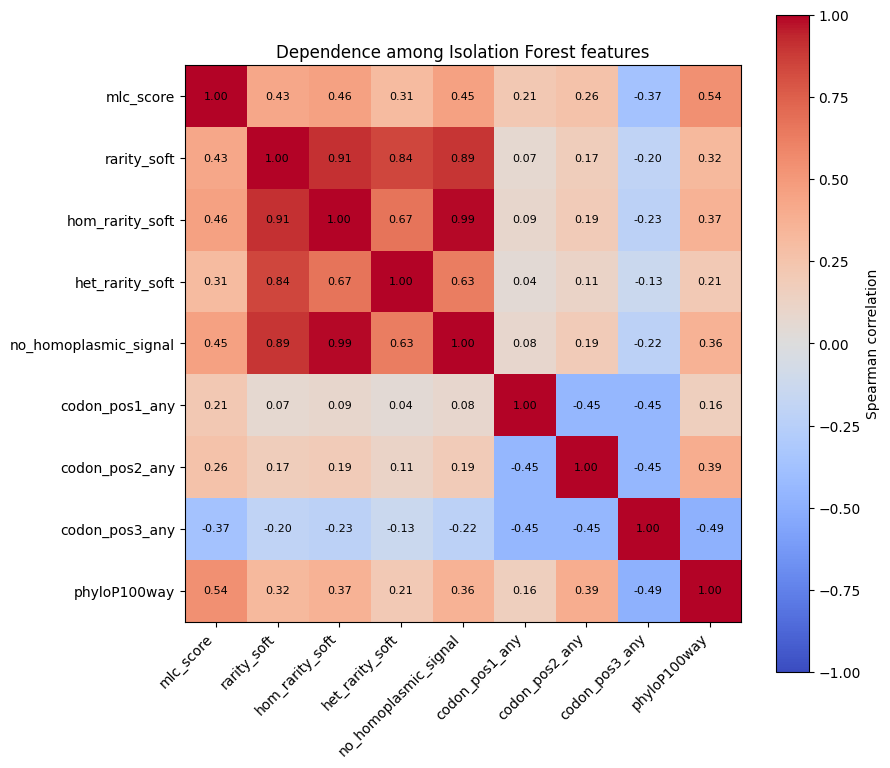

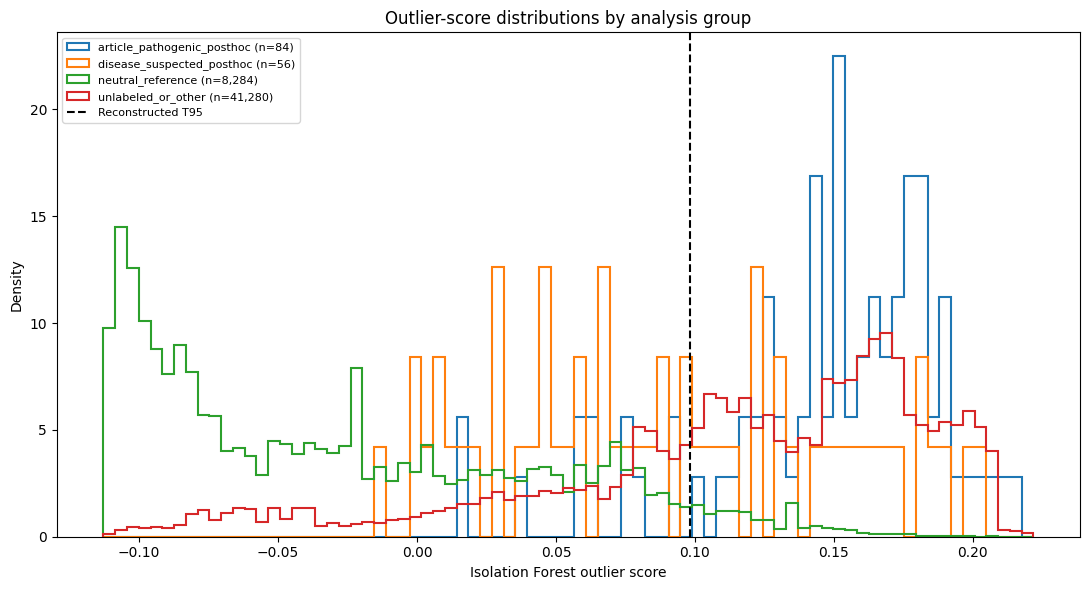

In [5]:
correlation_path = FIGURE_DIR / "feature_correlations_spearman.png"
score_distribution_path = FIGURE_DIR / "outlier_score_by_analysis_group.png"

fig, ax = plt.subplots(figsize=(9, 8))
image = ax.imshow(feature_correlation.to_numpy(), vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(np.arange(len(FEATURE_COLS)))
ax.set_yticks(np.arange(len(FEATURE_COLS)))
ax.set_xticklabels(FEATURE_COLS, rotation=45, ha="right")
ax.set_yticklabels(FEATURE_COLS)
for row_index in range(len(FEATURE_COLS)):
    for col_index in range(len(FEATURE_COLS)):
        ax.text(
            col_index, row_index,
            f"{feature_correlation.iloc[row_index, col_index]:.2f}",
            ha="center", va="center", fontsize=8,
        )
fig.colorbar(image, ax=ax, label="Spearman correlation")
ax.set_title("Dependence among Isolation Forest features")
fig.tight_layout()
fig.savefig(correlation_path, dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(11, 6))
bins = np.linspace(float(baseline_scores.min()), float(baseline_scores.max()), 80)
for group_name in sorted(scored["analysis_group"].dropna().unique()):
    group_values = baseline_scores[scored["analysis_group"].eq(group_name).to_numpy()]
    ax.hist(
        group_values, bins=bins, density=True, histtype="step",
        linewidth=1.5, label=f"{group_name} (n={len(group_values):,})",
    )
ax.axvline(ACTIVE_T95_THRESHOLD, color="black", linestyle="--", label="Reconstructed T95")
ax.set_xlabel("Isolation Forest outlier score")
ax.set_ylabel("Density")
ax.set_title("Outlier-score distributions by analysis group")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(score_distribution_path, dpi=300, bbox_inches="tight")
plt.show()

## Fixed-model permutation influence

Each feature is independently shuffled while the fitted forest remains fixed. A feature is influential when shuffling it changes scores, ranks, or T95 assignments. This measures reliance of the current fitted model on a feature, but correlated features and unrealistic shuffled combinations can affect the result. Five deterministic repeats quantify Monte Carlo variability.

In [6]:
evaluation_scopes = {
    "all_variants": np.ones(len(scored), dtype=bool),
    "neutral_validation": validation_mask,
    "unlabeled_or_other": unlabeled_mask,
}
permutation_rows = []
for feature_index, feature in enumerate(FEATURE_COLS):
    for repeat in range(PERMUTATION_REPEATS):
        rng = np.random.default_rng(10_000 + feature_index * 100 + repeat)
        permuted = X_all.copy()
        permuted[feature] = rng.permutation(permuted[feature].to_numpy())
        permuted_scores = outlier_score(baseline_model, permuted)
        permuted_flags = permuted_scores > ACTIVE_T95_THRESHOLD

        for scope_name, scope_mask in evaluation_scopes.items():
            baseline_subset = baseline_scores[scope_mask]
            permuted_subset = permuted_scores[scope_mask]
            baseline_flag_subset = active_flags[scope_mask]
            permuted_flag_subset = permuted_flags[scope_mask]
            permutation_rows.append({
                "feature": feature,
                "repeat": repeat,
                "scope": scope_name,
                "n": int(scope_mask.sum()),
                "mean_absolute_score_change": float(
                    np.mean(np.abs(permuted_subset - baseline_subset))
                ),
                "mean_signed_score_change": float(
                    np.mean(permuted_subset - baseline_subset)
                ),
                "score_spearman": spearman_rank_correlation(
                    baseline_subset, permuted_subset
                ),
                "t95_flip_fraction": float(
                    np.mean(baseline_flag_subset != permuted_flag_subset)
                ),
                "above_t95_jaccard": flag_jaccard(
                    baseline_flag_subset, permuted_flag_subset
                ),
            })

permutation_detail = pd.DataFrame(permutation_rows)
permutation_summary = (
    permutation_detail.groupby(["feature", "scope"], as_index=False)
    .agg(
        n=("n", "first"),
        mean_absolute_score_change=("mean_absolute_score_change", "mean"),
        sd_absolute_score_change=("mean_absolute_score_change", "std"),
        mean_signed_score_change=("mean_signed_score_change", "mean"),
        score_spearman=("score_spearman", "mean"),
        sd_score_spearman=("score_spearman", "std"),
        t95_flip_fraction=("t95_flip_fraction", "mean"),
        sd_t95_flip_fraction=("t95_flip_fraction", "std"),
        above_t95_jaccard=("above_t95_jaccard", "mean"),
    )
)
permutation_detail.to_csv(PERMUTATION_DETAIL_OUTPUT, sep="\t", index=False)
permutation_summary.to_csv(PERMUTATION_SUMMARY_OUTPUT, sep="\t", index=False)

print("Saved:", PERMUTATION_SUMMARY_OUTPUT)
display(
    permutation_summary[permutation_summary["scope"] == "all_variants"]
    .sort_values("t95_flip_fraction", ascending=False)
)

Saved: ..\results\model_characterization\permutation_influence_summary.tsv


,feature,scope,n,mean_absolute_score_change,sd_absolute_score_change,mean_signed_score_change,score_spearman,sd_score_spearman,t95_flip_fraction,sd_t95_flip_fraction,above_t95_jaccard
15,mlc_score,all_variants,49704,0.031985,0.000142,0.009729,0.900982,0.000730,0.090234,0.000997,0.856980
6,codon_pos3_any,all_variants,49704,0.021851,0.000095,0.008853,0.930548,0.000326,0.089743,0.001259,0.856182
3,codon_pos2_any,all_variants,49704,0.024761,0.000117,0.003089,0.829180,0.000674,0.087760,0.000477,0.859698
21,phyloP100way,all_variants,49704,0.019353,0.000045,0.003911,0.960756,0.000091,0.082005,0.001118,0.867177
18,no_homoplasmic_signal,all_variants,49704,0.015292,0.000038,0.009760,0.957771,0.000107,0.061420,0.000384,0.900932
0,codon_pos1_any,all_variants,49704,0.008874,0.000051,0.004357,0.986404,0.000076,0.052410,0.000561,0.912414
24,rarity_soft,all_variants,49704,0.011024,0.000058,0.009059,0.987431,0.000059,0.038182,0.000283,0.936970
9,het_rarity_soft,all_variants,49704,0.009109,0.000056,0.006348,0.981632,0.000158,0.035836,0.000505,0.940407
12,hom_rarity_soft,all_variants,49704,0.008630,0.000034,0.006655,0.991583,0.000067,0.025233,0.000564,0.957404


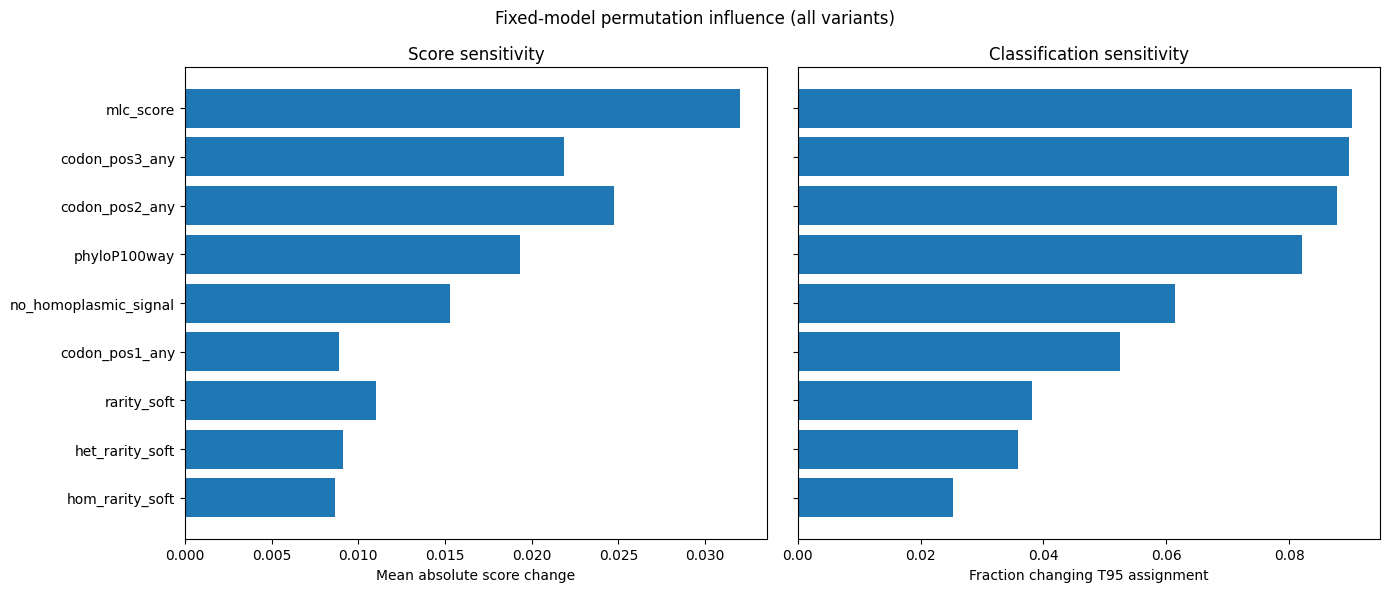

In [7]:
permutation_path = FIGURE_DIR / "permutation_influence.png"
permutation_plot = (
    permutation_summary[permutation_summary["scope"] == "all_variants"]
    .sort_values("t95_flip_fraction", ascending=True)
)
y = np.arange(len(permutation_plot))
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
axes[0].barh(y, permutation_plot["mean_absolute_score_change"])
axes[0].set_xlabel("Mean absolute score change")
axes[0].set_yticks(y)
axes[0].set_yticklabels(permutation_plot["feature"])
axes[0].set_title("Score sensitivity")
axes[1].barh(y, permutation_plot["t95_flip_fraction"])
axes[1].set_xlabel("Fraction changing T95 assignment")
axes[1].set_title("Classification sensitivity")
fig.suptitle("Fixed-model permutation influence (all variants)")
fig.tight_layout()
fig.savefig(permutation_path, dpi=300, bbox_inches="tight")
plt.show()

## Leave-one-feature-out refits and seed stability

The model is refitted after omitting one feature. For each reduced model, T95 is recalibrated on the same held-out neutral-validation set. Three paired random seeds reduce dependence on one forest realization. Full-model fits at the same seeds provide a stochastic-stability reference: an omission effect comparable to ordinary seed-to-seed variation is weak evidence of unique feature importance.

In [8]:
full_models_by_seed = {}
full_scores_by_seed = {}
full_thresholds_by_seed = {}
lofo_rows = []

for random_state in LOFO_RANDOM_STATES:
    full_model = fit_isolation_forest(FEATURE_COLS, random_state)
    full_scores = outlier_score(full_model, X_all)
    full_threshold = float(np.quantile(full_scores[validation_mask], 0.95))
    full_flags = full_scores > full_threshold
    full_models_by_seed[random_state] = full_model
    full_scores_by_seed[random_state] = full_scores
    full_thresholds_by_seed[random_state] = full_threshold

    for omitted_feature in FEATURE_COLS:
        reduced_features = [
            feature for feature in FEATURE_COLS if feature != omitted_feature
        ]
        reduced_model = fit_isolation_forest(reduced_features, random_state)
        reduced_scores = outlier_score(reduced_model, X_all[reduced_features])
        reduced_threshold = float(
            np.quantile(reduced_scores[validation_mask], 0.95)
        )
        reduced_flags = reduced_scores > reduced_threshold
        lofo_rows.append({
            "omitted_feature": omitted_feature,
            "random_state": random_state,
            "full_threshold": full_threshold,
            "reduced_threshold": reduced_threshold,
            "mean_absolute_score_change": float(
                np.mean(np.abs(reduced_scores - full_scores))
            ),
            "score_spearman": spearman_rank_correlation(
                full_scores, reduced_scores
            ),
            "t95_flip_fraction_all": float(
                np.mean(full_flags != reduced_flags)
            ),
            "t95_flip_fraction_neutral_validation": float(
                np.mean(full_flags[validation_mask] != reduced_flags[validation_mask])
            ),
            "t95_flip_fraction_unlabeled": float(
                np.mean(full_flags[unlabeled_mask] != reduced_flags[unlabeled_mask])
            ),
            "above_t95_jaccard": flag_jaccard(full_flags, reduced_flags),
        })

lofo_detail = pd.DataFrame(lofo_rows)
lofo_summary = (
    lofo_detail.groupby("omitted_feature", as_index=False)
    .agg(
        mean_absolute_score_change=("mean_absolute_score_change", "mean"),
        sd_absolute_score_change=("mean_absolute_score_change", "std"),
        score_spearman=("score_spearman", "mean"),
        sd_score_spearman=("score_spearman", "std"),
        t95_flip_fraction_all=("t95_flip_fraction_all", "mean"),
        sd_t95_flip_fraction_all=("t95_flip_fraction_all", "std"),
        t95_flip_fraction_neutral_validation=(
            "t95_flip_fraction_neutral_validation", "mean"
        ),
        t95_flip_fraction_unlabeled=("t95_flip_fraction_unlabeled", "mean"),
        above_t95_jaccard=("above_t95_jaccard", "mean"),
    )
)

reference_scores = full_scores_by_seed[RANDOM_STATE]
reference_threshold = full_thresholds_by_seed[RANDOM_STATE]
reference_flags = reference_scores > reference_threshold
seed_rows = []
for random_state in LOFO_RANDOM_STATES:
    candidate_scores = full_scores_by_seed[random_state]
    candidate_flags = candidate_scores > full_thresholds_by_seed[random_state]
    seed_rows.append({
        "reference_random_state": RANDOM_STATE,
        "candidate_random_state": random_state,
        "mean_absolute_score_change": float(
            np.mean(np.abs(candidate_scores - reference_scores))
        ),
        "score_spearman": spearman_rank_correlation(
            reference_scores, candidate_scores
        ),
        "t95_flip_fraction_all": float(
            np.mean(reference_flags != candidate_flags)
        ),
        "above_t95_jaccard": flag_jaccard(reference_flags, candidate_flags),
    })
seed_stability = pd.DataFrame(seed_rows)

lofo_detail.to_csv(LOFO_DETAIL_OUTPUT, sep="\t", index=False)
lofo_summary.to_csv(LOFO_SUMMARY_OUTPUT, sep="\t", index=False)
seed_stability.to_csv(SEED_STABILITY_OUTPUT, sep="\t", index=False)

print("Saved:", LOFO_SUMMARY_OUTPUT)
display(lofo_summary.sort_values("t95_flip_fraction_all", ascending=False))
display(seed_stability)

Saved: ..\results\model_characterization\leave_one_feature_out_summary.tsv


,omitted_feature,mean_absolute_score_change,sd_absolute_score_change,score_spearman,sd_score_spearman,t95_flip_fraction_all,sd_t95_flip_fraction_all,t95_flip_fraction_neutral_validation,t95_flip_fraction_unlabeled,above_t95_jaccard
7,phyloP100way,0.015078,0.001614,0.974722,0.002429,0.139043,0.006838,0.016256,0.163639,0.759042
1,codon_pos2_any,0.021495,0.003026,0.905612,0.005875,0.087525,0.017191,0.039112,0.096786,0.864539
6,no_homoplasmic_signal,0.012845,0.002368,0.983966,0.001858,0.086767,0.023898,0.018671,0.100525,0.850621
0,codon_pos1_any,0.012905,0.001881,0.986969,0.004154,0.071034,0.015911,0.020924,0.081177,0.880452
5,mlc_score,0.020642,0.001179,0.960245,0.001673,0.065105,0.011677,0.028972,0.072287,0.894202
2,codon_pos3_any,0.012499,0.001196,0.986462,0.001417,0.041372,0.003952,0.012232,0.047658,0.931214
3,het_rarity_soft,0.014291,0.002962,0.993651,0.000840,0.029086,0.009321,0.011589,0.031896,0.951090
4,hom_rarity_soft,0.009343,0.002969,0.993435,0.001440,0.024378,0.002605,0.010945,0.026058,0.958434
8,rarity_soft,0.009453,0.001463,0.994927,0.000943,0.020944,0.003680,0.011106,0.021940,0.964207


,reference_random_state,candidate_random_state,mean_absolute_score_change,score_spearman,t95_flip_fraction_all,above_t95_jaccard
0,42,42,0.000000,1.000000,0.000000,1.000000
1,42,43,0.005590,0.996249,0.022815,0.961272
2,42,44,0.005777,0.997892,0.014848,0.974247


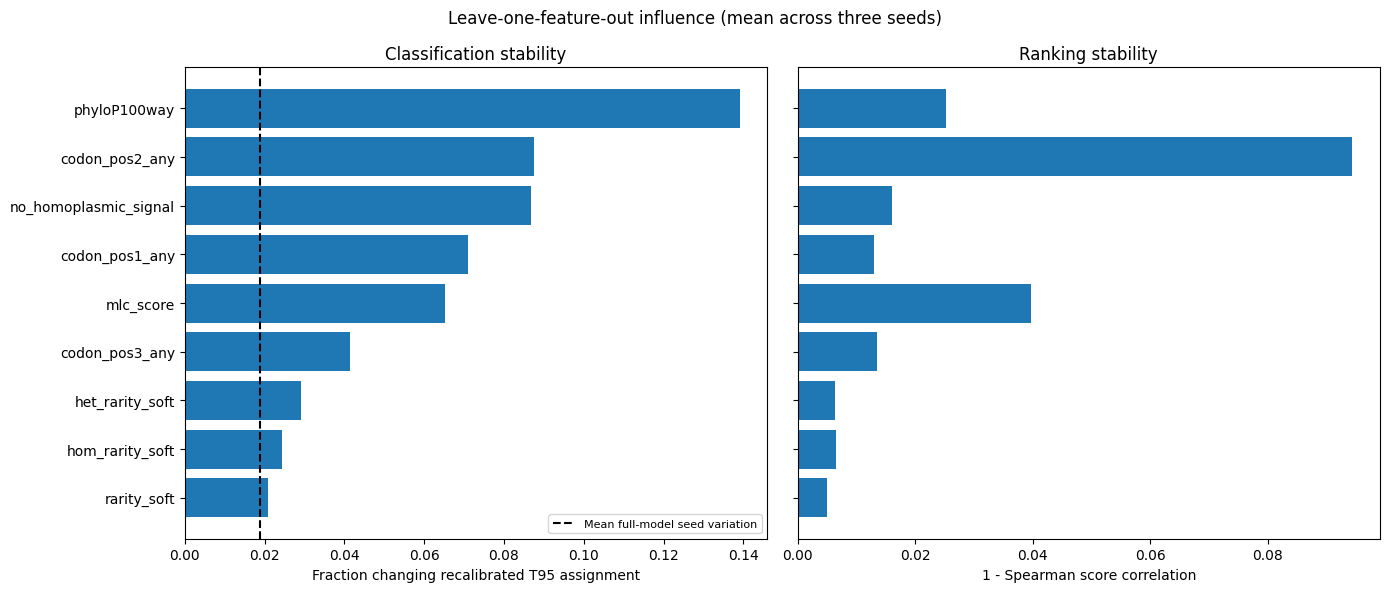

In [9]:
lofo_path = FIGURE_DIR / "leave_one_feature_out_influence.png"
lofo_plot = lofo_summary.sort_values("t95_flip_fraction_all", ascending=True)
y = np.arange(len(lofo_plot))
seed_floor = seed_stability.loc[
    seed_stability["candidate_random_state"] != RANDOM_STATE,
    "t95_flip_fraction_all",
].mean()
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
axes[0].barh(y, lofo_plot["t95_flip_fraction_all"])
axes[0].axvline(
    seed_floor, color="black", linestyle="--",
    label="Mean full-model seed variation",
)
axes[0].set_xlabel("Fraction changing recalibrated T95 assignment")
axes[0].set_yticks(y)
axes[0].set_yticklabels(lofo_plot["omitted_feature"])
axes[0].set_title("Classification stability")
axes[0].legend(fontsize=8)
axes[1].barh(y, 1 - lofo_plot["score_spearman"])
axes[1].set_xlabel("1 - Spearman score correlation")
axes[1].set_title("Ranking stability")
fig.suptitle("Leave-one-feature-out influence (mean across three seeds)")
fig.tight_layout()
fig.savefig(lofo_path, dpi=300, bbox_inches="tight")
plt.show()

## Local neutral-replacement influence

For each target variant, one feature at a time is replaced by 200 draws from the neutral-training distribution while every other feature remains fixed. The reported delta is `observed outlier score - counterfactual outlier score`. A positive mean delta means the observed value increases anomaly relative to typical neutral replacements; a negative value means it makes the variant look more neutral.

In [10]:
top_targets = scored.nlargest(LOCAL_TOP_N, "reconstructed_outlier_score").copy()
selected_targets = scored[scored["variant_id"].isin(SELECTED_LOCAL_VARIANTS)].copy()
targets = (
    pd.concat([top_targets, selected_targets], ignore_index=True)
    .drop_duplicates("variant_id")
    .sort_values("reconstructed_outlier_score", ascending=False)
    .reset_index(drop=True)
)
targets["target_order"] = np.arange(1, len(targets) + 1)
neutral_feature_values = X_train.reset_index(drop=True)
local_rows = []

for target in targets.itertuples(index=False):
    target_row = scored.loc[
        scored["variant_id"].eq(target.variant_id), FEATURE_COLS
    ].iloc[0]
    observed_score = float(target.reconstructed_outlier_score)

    for feature_index, feature in enumerate(FEATURE_COLS):
        rng = np.random.default_rng(50_000 + target.target_order * 100 + feature_index)
        replacement_values = rng.choice(
            neutral_feature_values[feature].to_numpy(),
            size=LOCAL_REPLACEMENT_DRAWS,
            replace=True,
        )
        counterfactual = pd.DataFrame(
            np.repeat(
                target_row.to_numpy(dtype=float)[None, :],
                LOCAL_REPLACEMENT_DRAWS,
                axis=0,
            ),
            columns=FEATURE_COLS,
        )
        counterfactual[feature] = replacement_values
        counterfactual_scores = outlier_score(baseline_model, counterfactual)
        score_delta = observed_score - counterfactual_scores
        local_rows.append({
            "variant_id": target.variant_id,
            "target_order": int(target.target_order),
            "analysis_group": target.analysis_group,
            "saved_above_T95": int(getattr(target, T95_FLAG_COL)),
            "reconstructed_above_T95": int(target.reconstructed_above_T95),
            "observed_outlier_score": observed_score,
            "feature": feature,
            "observed_feature_value": float(target_row[feature]),
            "neutral_train_median": float(
                neutral_feature_values[feature].median()
            ),
            "mean_observed_minus_counterfactual_score": float(
                score_delta.mean()
            ),
            "sd_observed_minus_counterfactual_score": float(
                score_delta.std(ddof=1)
            ),
            "fraction_replacements_lowering_score": float(
                np.mean(counterfactual_scores < observed_score)
            ),
            "fraction_replacements_inside_T95": float(
                np.mean(counterfactual_scores <= ACTIVE_T95_THRESHOLD)
            ),
        })

local_influence = pd.DataFrame(local_rows)
local_influence.to_csv(LOCAL_INFLUENCE_OUTPUT, sep="\t", index=False)
print("Local targets:", len(targets))
print("Saved:", LOCAL_INFLUENCE_OUTPUT)
display(
    local_influence.sort_values(
        ["target_order", "mean_observed_minus_counterfactual_score"],
        ascending=[True, False],
    ).groupby("variant_id", group_keys=False).head(3)
)

Local targets: 24
Saved: ..\results\model_characterization\local_neutral_replacement_influence.tsv


,variant_id,target_order,analysis_group,saved_above_T95,reconstructed_above_T95,observed_outlier_score,feature,observed_feature_value,neutral_train_median,mean_observed_minus_counterfactual_score,sd_observed_minus_counterfactual_score,fraction_replacements_lowering_score,fraction_replacements_inside_T95
0,m.8517G>A,1,unlabeled_or_other,1,1,0.221871,mlc_score,1.000000,0.000000,0.034477,0.005345,1.000,0.000
6,m.8517G>A,1,unlabeled_or_other,1,1,0.221871,codon_pos2_any,1.000000,0.000000,0.030341,0.009566,0.910,0.000
4,m.8517G>A,1,unlabeled_or_other,1,1,0.221871,no_homoplasmic_signal,1.000000,0.000000,0.026617,0.017053,0.710,0.000
9,m.6589T>C,2,unlabeled_or_other,1,1,0.221286,mlc_score,0.987870,0.000000,0.034637,0.004305,0.995,0.000
15,m.6589T>C,2,unlabeled_or_other,1,1,0.221286,codon_pos2_any,1.000000,0.000000,0.030401,0.009585,0.910,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,m.16519T>C,23,unlabeled_or_other,1,1,0.138358,rarity_soft,0.182268,4.047689,0.033443,0.010529,1.000,0.400
201,m.16519T>C,23,unlabeled_or_other,1,1,0.138358,het_rarity_soft,2.800582,5.214493,0.029269,0.010178,1.000,0.000
207,m.14149C>A,24,unlabeled_or_other,0,0,0.063230,mlc_score,0.700000,0.000000,0.078371,0.036343,0.935,0.980
215,m.14149C>A,24,unlabeled_or_other,0,0,0.063230,phyloP100way,0.298205,-8.109370,0.024203,0.024051,0.830,1.000


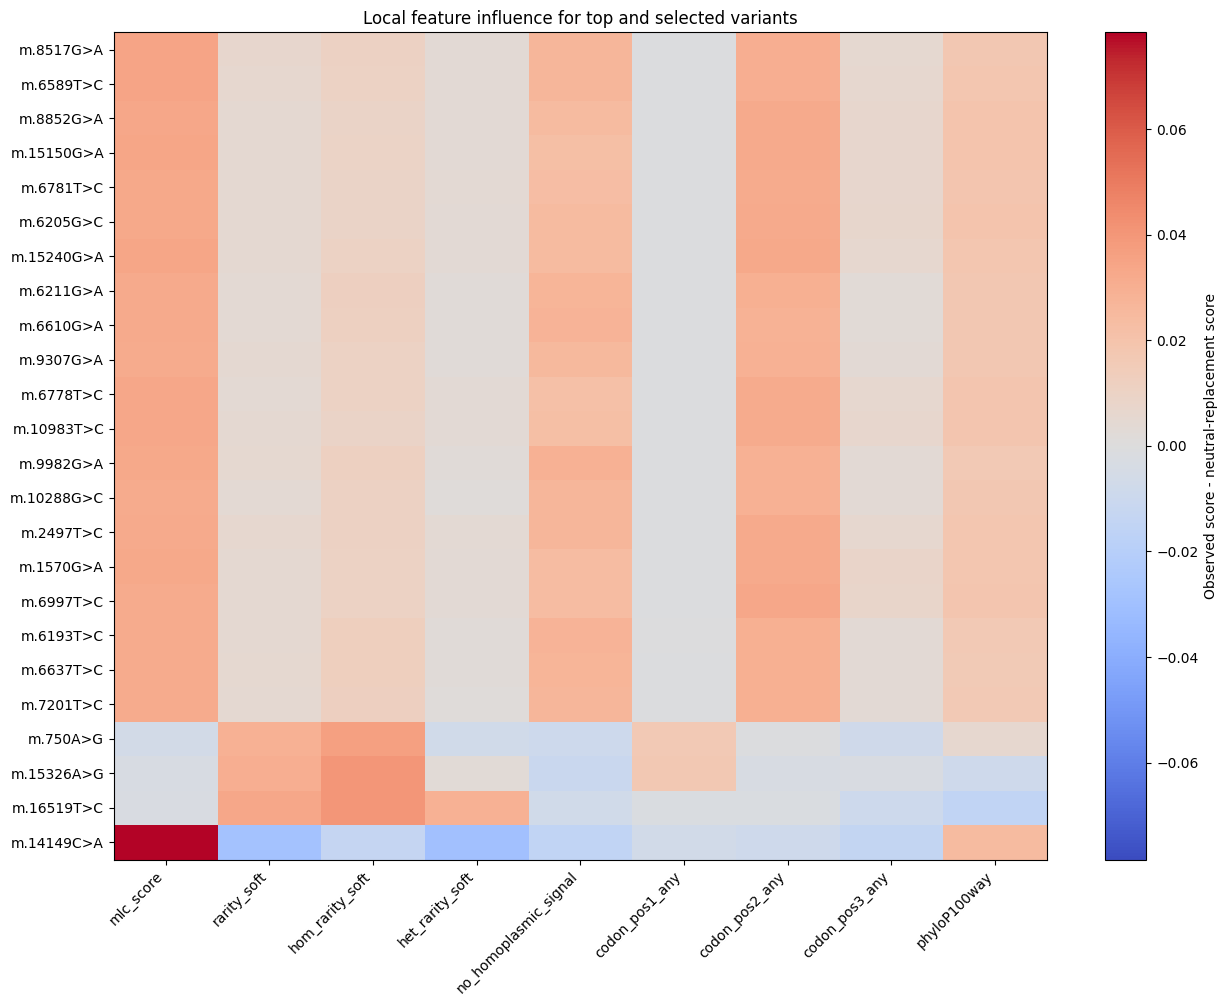

In [11]:
local_path = FIGURE_DIR / "local_neutral_replacement_influence.png"
local_matrix = (
    local_influence.pivot(
        index="variant_id",
        columns="feature",
        values="mean_observed_minus_counterfactual_score",
    )
    .reindex(index=targets["variant_id"], columns=FEATURE_COLS)
)
local_limit = float(np.abs(local_matrix.to_numpy()).max())
fig_height = max(7, 0.34 * len(local_matrix) + 2)
fig, ax = plt.subplots(figsize=(13, fig_height))
image = ax.imshow(
    local_matrix.to_numpy(),
    aspect="auto", cmap="coolwarm",
    vmin=-local_limit, vmax=local_limit,
)
ax.set_xticks(np.arange(len(FEATURE_COLS)))
ax.set_xticklabels(FEATURE_COLS, rotation=45, ha="right")
ax.set_yticks(np.arange(len(local_matrix)))
ax.set_yticklabels(local_matrix.index)
fig.colorbar(
    image, ax=ax,
    label="Observed score - neutral-replacement score",
)
ax.set_title("Local feature influence for top and selected variants")
fig.tight_layout()
fig.savefig(local_path, dpi=300, bbox_inches="tight")
plt.show()

## Consolidated feature readout

The final table places the two global diagnostics side by side. The ranks are descriptive ordering aids, not fitted coefficients. Strong evidence of unique influence requires agreement between fixed-model permutation and leave-one-feature-out results, with an omission effect larger than the seed-stability reference.

In [12]:
permutation_all = (
    permutation_summary[permutation_summary["scope"] == "all_variants"]
    [[
        "feature", "mean_absolute_score_change", "score_spearman",
        "t95_flip_fraction", "above_t95_jaccard",
    ]]
    .rename(columns={
        "mean_absolute_score_change": "permutation_mean_absolute_score_change",
        "score_spearman": "permutation_score_spearman",
        "t95_flip_fraction": "permutation_t95_flip_fraction",
        "above_t95_jaccard": "permutation_above_t95_jaccard",
    })
)
lofo_readout = lofo_summary.rename(columns={
    "omitted_feature": "feature",
    "mean_absolute_score_change": "lofo_mean_absolute_score_change",
    "score_spearman": "lofo_score_spearman",
    "t95_flip_fraction_all": "lofo_t95_flip_fraction_all",
    "above_t95_jaccard": "lofo_above_t95_jaccard",
})
feature_summary = permutation_all.merge(lofo_readout, on="feature", how="inner")
feature_summary["permutation_influence_rank"] = (
    feature_summary["permutation_t95_flip_fraction"]
    .rank(method="min", ascending=False).astype(int)
)
feature_summary["lofo_influence_rank"] = (
    feature_summary["lofo_t95_flip_fraction_all"]
    .rank(method="min", ascending=False).astype(int)
)
feature_summary["mean_full_model_seed_t95_flip_fraction"] = float(seed_floor)
feature_summary = feature_summary.sort_values(
    ["permutation_influence_rank", "lofo_influence_rank"]
)
feature_summary.to_csv(FEATURE_SUMMARY_OUTPUT, sep="\t", index=False)

print("Saved primary readout:", FEATURE_SUMMARY_OUTPUT)
print("Mean full-model seed T95 flip fraction:", float(seed_floor))
display(feature_summary)

Saved primary readout: ..\results\model_characterization\feature_influence_summary.tsv
Mean full-model seed T95 flip fraction: 0.01883148237566393


,feature,permutation_mean_absolute_score_change,permutation_score_spearman,permutation_t95_flip_fraction,permutation_above_t95_jaccard,lofo_mean_absolute_score_change,sd_absolute_score_change,lofo_score_spearman,sd_score_spearman,lofo_t95_flip_fraction_all,sd_t95_flip_fraction_all,t95_flip_fraction_neutral_validation,t95_flip_fraction_unlabeled,lofo_above_t95_jaccard,permutation_influence_rank,lofo_influence_rank,mean_full_model_seed_t95_flip_fraction
5,mlc_score,0.031985,0.900982,0.090234,0.856980,0.020642,0.001179,0.960245,0.001673,0.065105,0.011677,0.028972,0.072287,0.894202,1,5,0.018831
2,codon_pos3_any,0.021851,0.930548,0.089743,0.856182,0.012499,0.001196,0.986462,0.001417,0.041372,0.003952,0.012232,0.047658,0.931214,2,6,0.018831
1,codon_pos2_any,0.024761,0.829180,0.087760,0.859698,0.021495,0.003026,0.905612,0.005875,0.087525,0.017191,0.039112,0.096786,0.864539,3,2,0.018831
7,phyloP100way,0.019353,0.960756,0.082005,0.867177,0.015078,0.001614,0.974722,0.002429,0.139043,0.006838,0.016256,0.163639,0.759042,4,1,0.018831
6,no_homoplasmic_signal,0.015292,0.957771,0.061420,0.900932,0.012845,0.002368,0.983966,0.001858,0.086767,0.023898,0.018671,0.100525,0.850621,5,3,0.018831
0,codon_pos1_any,0.008874,0.986404,0.052410,0.912414,0.012905,0.001881,0.986969,0.004154,0.071034,0.015911,0.020924,0.081177,0.880452,6,4,0.018831
8,rarity_soft,0.011024,0.987431,0.038182,0.936970,0.009453,0.001463,0.994927,0.000943,0.020944,0.003680,0.011106,0.021940,0.964207,7,9,0.018831
3,het_rarity_soft,0.009109,0.981632,0.035836,0.940407,0.014291,0.002962,0.993651,0.000840,0.029086,0.009321,0.011589,0.031896,0.951090,8,7,0.018831
4,hom_rarity_soft,0.008630,0.991583,0.025233,0.957404,0.009343,0.002969,0.993435,0.001440,0.024378,0.002605,0.010945,0.026058,0.958434,9,8,0.018831


## Interpretation limits

- Isolation Forest identifies unusual multivariate combinations; it does not estimate causal or signed biological effects.
- `RobustScaler` does not create feature weights. It applies a deterministic marginal transformation before the forest.
- Correlated rarity features can substitute for each other, reducing leave-one-out effects while increasing group-level reliance on population information.
- Codon-position indicators are mutually exclusive for coding variants and all zero for non-coding variants; they should be interpreted as one feature family.
- Permutation can create feature combinations that are uncommon or impossible in the original data.
- Local neutral replacement is a one-feature counterfactual diagnostic, not a decomposition whose values sum to the model score.
- Population-frequency-derived inputs helped define the Isolation Forest groups, so later population-weighted mutation spectra are descriptive rather than independent validation.